**שלב 1: טעינה חכמה ושמירה על המזהים המקוריים (IDs)**


בשלב זה נטען את הנתונים, נוודא שהתאריכים תקינים, ונוודא שאנחנו שומרים את ה-_id של כל שורה (גם של שאלון PANAS וגם של דיווח ה-EMA).

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
DATA_DIR = PROJECT_ROOT / "data" / "processed_parquet"

# בדיקה שהתיקייה אכן קיימת במחשב של המשתמשת
if not DATA_DIR.exists():
    raise FileNotFoundError(f"⚠️ התיקייה לא נמצאה בנתיב: {DATA_DIR}\nאנא ודאי שמבנה התיקיות בפרויקט תואם.")
else:
    print(f"✅ נתיב הנתונים נקלט בהצלחה: {DATA_DIR}")

✅ נתיב הנתונים נקלט בהצלחה: c:\Users\moria\Documents\projects\lifesnaps_project\data\processed_parquet


In [21]:
panas_raw = pd.read_parquet(DATA_DIR / "panas.parquet")
sema_raw = pd.read_parquet(DATA_DIR / "all_sema_emotions.parquet")

# 1.A. הכנת טבלת הבסיס ל-PANAS
panas_base = panas_raw.copy()
# יצירת המזהה המקורי לשאלון - נמנע משגיאת חוסר בעמודה (KeyError)
if '_id' in panas_base.columns:
    panas_base['panas_original_id'] = panas_base['_id'].astype(str)
elif 'id' in panas_base.columns and panas_base['id'].nunique() == len(panas_base): 
    panas_base['panas_original_id'] = panas_base['id'].astype(str)
else:
    panas_base['panas_original_id'] = ["panas_" + str(i) for i in range(len(panas_base))]

panas_user_col = next((col for col in ['user_id', 'participant_id', 'id'] if col in panas_base.columns), None)
panas_base['user_id'] = panas_base[panas_user_col].astype(str).str.strip()
panas_date_col = 'submitdate' if 'submitdate' in panas_base.columns else 'date'
panas_base['panas_date'] = pd.to_datetime(panas_base[panas_date_col], errors='coerce').dt.normalize()

# סינון שאלונים ריקים וחישוב פער ימים (ישמש את שתי הגישות)
panas_base = panas_base.dropna(subset=['panas_original_id', 'user_id', 'panas_date', 'positive_affect_score', 'negative_affect_score']).copy()
panas_base = panas_base.sort_values(by=['user_id', 'panas_date']).reset_index(drop=True)
panas_base['days_since_last_panas'] = panas_base.groupby('user_id')['panas_date'].diff().dt.days


# 1.B. הכנת טבלת הבסיס ל-EMA
ema_base = sema_raw.copy()
if '_id' in ema_base.columns:
    ema_base['ema_original_id'] = ema_base['_id'].astype(str)
elif 'id' in ema_base.columns and ema_base['id'].nunique() == len(ema_base):
    ema_base['ema_original_id'] = ema_base['id'].astype(str)
else:
    ema_base['ema_original_id'] = ["ema_" + str(i) for i in range(len(ema_base))]

ema_user_col = next((col for col in ['participant_id', 'user_id', 'data.PARTICIPANT_ID'] if col in ema_base.columns), None)
ema_base['user_id'] = ema_base[ema_user_col].astype(str).str.strip()
sema_ts_col = 'data.COMPLETED_TS' if 'data.COMPLETED_TS' in ema_base.columns else 'timestamp'
ema_base['ema_timestamp'] = pd.to_datetime(ema_base[sema_ts_col], errors='coerce').dt.tz_localize(None)
ema_base['ema_date'] = ema_base['ema_timestamp'].dt.normalize()

# סינון דיווחים ריקים או ללא רגש תקין
ema_base = ema_base.dropna(subset=['ema_original_id', 'user_id', 'ema_date', 'data.MOOD']).copy()
ema_base = ema_base[ema_base['data.MOOD'] != '<no-response>']

print(f"✅ שלב 1 הושלם. נטענו {len(panas_base)} שאלוני PANAS ו-{len(ema_base)} דיווחי EMA.\n")



✅ שלב 1 הושלם. נטענו 268 שאלוני PANAS ו-5036 דיווחי EMA.



In [ ]:
** שלב 2: גישה א' - מסגרת זמן קבועה ונוקשה (Rigid 7-Days Window) **
#
#בגישה זו אנו הולכים תמיד 7 ימים אחורה. לאחר מכן נסנן את האלונים
# שיש בהם חפיפה או שחסרים בהם נתונים מספקים (נצפה ל-165 שאלונים נקיים בסוף).

טיפול בבעיות שהתגלו ב-Sanity Checks
ביקשת לחשוב מה עושים עם החפיפות.
המלצה שלי למודל אמין: אם לנבדק יש שני שאלוני PANAS בהפרש של 3 ימים (לדוגמה ראשון ורביעי), הנתונים של ראשון-רביעי ייכנסו לשני המודלים וייצרו כפילות (Data Leakage פנימי). עדיף לסנן שאלונים חופפים ולהשאיר רק חלונות נקיים של 7 ימים. כמו כן, נסנן גם שבועות שיש בהם מעט מדי דיווחים (למשל פחות מ-3 דיווחים בשבוע, כי אי אפשר לייצג שבוע מדיווח בודד).

In [29]:
# =====================================================================
# שלב 2: גישה א' - מסגרת זמן קבועה ונוקשה (Rigid 7-Days Window)
# =====================================================================
# בגישה זו אנו הולכים תמיד 7 ימים אחורה. לאחר מכן נסנן את השאלונים
# שיש בהם חפיפה או שחסרים בהם נתונים מספקים (נצפה ל-165 שאלונים נקיים בסוף).
print("=== שלב 2: גישה א' - חלון זמן קבוע של 7 ימים (Rigid Window) ===")

rigid_records = []

for _, p_row in panas_base.iterrows():
    is_overlapping = pd.notna(p_row['days_since_last_panas']) and p_row['days_since_last_panas'] < 7
    start_date = p_row['panas_date'] - pd.Timedelta(days=7) # תמיד 7 ימים אחורה
    
    user_emas = ema_base[ema_base['user_id'] == p_row['user_id']]
    valid_emas = user_emas[(user_emas['ema_date'] > start_date) & (user_emas['ema_date'] <= p_row['panas_date'])]
    
    if len(valid_emas) > 0: # שומרים רק אם יש לפחות דיווח אחד ב-7 הימים
        for _, ema_row in valid_emas.iterrows():
            rigid_records.append({
                'user_id': p_row['user_id'],
                'panas_original_id': p_row['panas_original_id'],
                'panas_date': p_row['panas_date'],
                'positive_affect_score': p_row['positive_affect_score'],
                'negative_affect_score': p_row['negative_affect_score'],
                'is_overlapping_window': is_overlapping,
                'total_emas_in_window': len(valid_emas),
                'ema_original_id': ema_row['ema_original_id'],
                'data.MOOD': ema_row['data.MOOD']
            })

rigid_long_df = pd.DataFrame(rigid_records)


# ---------------------------------------------------------------------
# הרצת בדיקת שפיות ומעקב סינון נתונים (Data Funnel) עבור הגישה הקשיחה
# משתנים עם קידומת rigid_ למניעת דריסה עתידית
# ---------------------------------------------------------------------
print("\n=== מעקב סינון נתונים בגישה הקשיחה (Data Funnel) ===")

rigid_initial_count = len(panas_base)
print(f"1. התחלנו עם: {rigid_initial_count} שאלוני PANAS תקינים בבסיס.")

# 1. כמה שאלונים נמחקו כי לא היו להם דיווחי EMA בכלל?
rigid_with_any_ema = rigid_long_df['panas_original_id'].nunique()
rigid_no_ema_count = rigid_initial_count - rigid_with_any_ema
print(f"   -> נמחקו {rigid_no_ema_count} שאלונים כי לא היו להם דיווחי EMA בכלל ב-7 הימים שקדמו להם.")

# 2. מתוך אלו שנשארו, כמה נמחקו בגלל חפיפה עם שאלון קודם?
rigid_overlapping_count = rigid_long_df[rigid_long_df['is_overlapping_window'] == True]['panas_original_id'].nunique()
print(f"   -> נמחקו {rigid_overlapping_count} שאלונים בגלל חפיפת זמנים (פחות מ-7 ימים מהשאלון הקודם של הנבדק).")

# 3. מתוך אלו שלא חופפים, כמה נמחקו כי היו להם פחות מ-3 דיווחים?
rigid_sparse_count = rigid_long_df[(rigid_long_df['is_overlapping_window'] == False) & (rigid_long_df['total_emas_in_window'] < 3)]['panas_original_id'].nunique()
print(f"   -> נמחקו {rigid_sparse_count} שאלונים כי היו להם פחות מ-3 דיווחים (לא מספיק כדי לחשב ממוצע שבועי אמין).")

# חישוב הסך הכל המוזהב
rigid_final_gold_count = rigid_with_any_ema - rigid_overlapping_count - rigid_sparse_count
print(f"\n✅ נשארנו עם: {rigid_final_gold_count} שאלוני PANAS מוזהבים למודל בגישה הקשיחה.\n")


# ---------------------------------------------------------------------
# החלת מסנני האיכות (Sanity Checks) ויצירת הטבלה הארוכה הנקייה
# ---------------------------------------------------------------------
rigid_clean_long_df = rigid_long_df[
    (rigid_long_df['is_overlapping_window'] == False) & # ללא חפיפות
    (rigid_long_df['total_emas_in_window'] >= 3)        # לפחות 3 דיווחים לייצוג השבוע
].copy()


# ---------------------------------------------------------------------
# אגרגציה מפורמט ארוך לפורמט רחב (Wide Format) למודל
# ---------------------------------------------------------------------
mood_dummies_rigid = pd.get_dummies(rigid_clean_long_df['data.MOOD'], prefix='mood')
rigid_wide_prep = pd.concat([rigid_clean_long_df, mood_dummies_rigid], axis=1)

agg_funcs_rigid = {
    'user_id': 'first', 
    'panas_date': 'first', 
    'positive_affect_score': 'first', 
    'negative_affect_score': 'first', 
    'total_emas_in_window': 'first'
}
for col in mood_dummies_rigid.columns:
    agg_funcs_rigid[col] = 'mean' # חישוב התפלגות הרגשות (אחוז מתוך הדיווחים)

rigid_wide_df = rigid_wide_prep.groupby('panas_original_id').agg(agg_funcs_rigid).reset_index()

print(f"✅ אגרגציה הושלמה: נוצרה טבלת rigid_wide_df עם {len(rigid_wide_df)} תצפיות ייחודיות.\n")
display(rigid_wide_df.head(100))

=== שלב 2: גישה א' - חלון זמן קבוע של 7 ימים (Rigid Window) ===

=== מעקב סינון נתונים בגישה הקשיחה (Data Funnel) ===
1. התחלנו עם: 268 שאלוני PANAS תקינים בבסיס.
   -> נמחקו 53 שאלונים כי לא היו להם דיווחי EMA בכלל ב-7 הימים שקדמו להם.
   -> נמחקו 33 שאלונים בגלל חפיפת זמנים (פחות מ-7 ימים מהשאלון הקודם של הנבדק).
   -> נמחקו 17 שאלונים כי היו להם פחות מ-3 דיווחים (לא מספיק כדי לחשב ממוצע שבועי אמין).

✅ נשארנו עם: 165 שאלוני PANAS מוזהבים למודל בגישה הקשיחה.

✅ אגרגציה הושלמה: נוצרה טבלת rigid_wide_df עם 165 תצפיות ייחודיות.



,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_NEUTRAL,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,8,0.000000,0.125000,0.625000,0.125000,0.000000,0.000000,0.125000
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,14,0.000000,0.642857,0.000000,0.000000,0.000000,0.142857,0.214286
2,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,8,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.750000
3,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,3,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.666667
4,panas_102,621e310d67b776a24003096d,2021-12-27,33,19,6,0.000000,0.333333,0.000000,0.500000,0.000000,0.166667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,panas_221,621e34db67b776a240c9c2be,2021-06-22,37,27,4,0.000000,0.000000,0.000000,0.000000,0.250000,0.500000,0.250000
96,panas_222,621e34ec67b776a240d60873,2021-06-02,24,25,9,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.555556
97,panas_227,621e351a67b776a240f6204b,2021-06-14,31,18,17,0.000000,0.117647,0.235294,0.294118,0.000000,0.000000,0.352941
98,panas_228,621e351a67b776a240f6204b,2021-07-26,37,10,18,0.000000,0.000000,0.000000,0.722222,0.000000,0.000000,0.277778


**# שלב 3: גישה ב' - חלון זמן דינאמי מותאם אישית (Dynamic Window) - הגישה המועדפת**
בגלל שנשארו לנו רק 165 תצפיות של שאלוני PANAS זה קצת נתונים. 
אנחנו רוצים לראות האם יש דרך להציל חלק מהנתונים.
חשבנו להציל את הנתונים של השבועות שיש בינהם חפיפה
אז עברנו לגישה שעושה קבוצות של מידע, כאשר חלון הזמן הוא דינמי. ככה שלפעמים חלון הזמן של הרגשות הוא קטן יותר מאשר 7.
 עד השאלון הקודם כדי למנוע זליגת נתונים.
# אנו מאפשרים מינימום של דיווח אחד, כי המודל יקבל את גודל החלון כפיצ'ר וידע להתמודד.
# (נצפה ל-214 שאלונים נקיים בסוף).

In [28]:
# =====================================================================
# שלב 3: גישה ב' - חלון זמן דינאמי מותאם אישית (Dynamic Window) - הגישה המועדפת
# =====================================================================
# בגישה זו אנו הולכים 7 ימים אחורה, *או* עד השאלון הקודם כדי למנוע זליגת נתונים.
# אנו מאפשרים מינימום של דיווח אחד, כי המודל יקבל את גודל החלון כפיצ'ר וידע להתמודד.
# (נצפה ל-214 שאלונים נקיים בסוף).
print("=== שלב 3: גישה ב' - חלון זמן דינאמי (Dynamic Window) ===")

dynamic_records = []

for _, p_row in panas_base.iterrows():
    # הגדרת חלון דינאמי למניעת Leakage
    if pd.notna(p_row['days_since_last_panas']) and p_row['days_since_last_panas'] < 7:
        days_to_look_back = p_row['days_since_last_panas']
    else:
        days_to_look_back = 7
        
    start_date = p_row['panas_date'] - pd.Timedelta(days=days_to_look_back)
    
    user_emas = ema_base[ema_base['user_id'] == p_row['user_id']]
    valid_emas = user_emas[(user_emas['ema_date'] > start_date) & (user_emas['ema_date'] <= p_row['panas_date'])]
    
    ema_count = len(valid_emas)
    
    # אין צורך לדאוג מחפיפה, שומרים כל שאלון שיש לו לפחות דיווח 1 בחלון הדינאמי שלו
    if ema_count >= 1:
        for _, ema_row in valid_emas.iterrows():
            dynamic_records.append({
                'user_id': p_row['user_id'],
                'panas_original_id': p_row['panas_original_id'],
                'panas_date': p_row['panas_date'],
                'positive_affect_score': p_row['positive_affect_score'],
                'negative_affect_score': p_row['negative_affect_score'],
                'window_days_size': days_to_look_back, # נשמר כפיצ'ר ללמידת המכונה
                'total_emas_in_window': ema_count,     # נשמר כפיצ'ר ללמידת המכונה
                'ema_original_id': ema_row['ema_original_id'],
                'data.MOOD': ema_row['data.MOOD']
            })

dynamic_long_df = pd.DataFrame(dynamic_records)

# ---------------------------------------------------------------------
# הרצת בדיקת שפיות ומעקב סינון נתונים (Data Funnel) עבור הגישה הדינאמית
# ---------------------------------------------------------------------
print("\n=== מעקב סינון נתונים בגישה הדינאמית (Data Funnel) ===")

dynamic_initial_count = len(panas_base)
print(f"1. התחלנו עם: {dynamic_initial_count} שאלוני PANAS תקינים בבסיס.")

# 1. כמה נמחקו כי לא היו להם דיווחים כלל בחלון הדינאמי?
dynamic_final_gold_count = dynamic_long_df['panas_original_id'].nunique()
dynamic_no_ema_count = dynamic_initial_count - dynamic_final_gold_count
print(f"   -> נמחקו {dynamic_no_ema_count} שאלונים כי לא היו להם דיווחי EMA כלל בחלון הזמן המותאם שלהם.")

# 2. דיווח על חפיפות (בגישה זו טיפלנו בהן אקטיבית)
print(f"   -> נמחקו 0 שאלונים בגלל חפיפת זמנים (החלון הדינאמי מונע זליגה באופן אוטומטי).")

# 3. דיווח על שאלונים דלילים (בגישה זו אנו שומרים אותם כפיצ'ר)
print(f"   -> נמחקו 0 שאלונים בגלל חוסר דיווחים (הורדנו את הרף לדיווח בודד, גודל החלון נשמר כפיצ'ר).")

print(f"\n✅ נשארנו עם: {dynamic_final_gold_count} שאלוני PANAS מוזהבים למודל בגישה הדינאמית.\n")

# ---------------------------------------------------------------------
# אגרגציה מפורמט ארוך לפורמט רחב (Wide Format) למודל
# ---------------------------------------------------------------------
mood_dummies_dyn = pd.get_dummies(dynamic_long_df['data.MOOD'], prefix='mood')
dynamic_wide_prep = pd.concat([dynamic_long_df, mood_dummies_dyn], axis=1)

agg_funcs_dyn = {
    'user_id': 'first', 'panas_date': 'first', 
    'positive_affect_score': 'first', 'negative_affect_score': 'first', 
    'window_days_size': 'first', 'total_emas_in_window': 'first'
}
for col in mood_dummies_dyn.columns:
    agg_funcs_dyn[col] = 'mean' # חישוב התפלגות הרגשות (אחוז מתוך הדיווחים)

dynamic_wide_df = dynamic_wide_prep.groupby('panas_original_id').agg(agg_funcs_dyn).reset_index()
print(f"✅ אגרגציה הושלמה: נוצרה טבלת dynamic_wide_df עם {len(dynamic_wide_df)} תצפיות ייחודיות (נטולות חפיפה).\n")
display(dynamic_wide_df.head(100))

=== שלב 3: גישה ב' - חלון זמן דינאמי (Dynamic Window) ===

=== מעקב סינון נתונים בגישה הדינאמית (Data Funnel) ===
1. התחלנו עם: 268 שאלוני PANAS תקינים בבסיס.
   -> נמחקו 54 שאלונים כי לא היו להם דיווחי EMA כלל בחלון הזמן המותאם שלהם.
   -> נמחקו 0 שאלונים בגלל חפיפת זמנים (החלון הדינאמי מונע זליגה באופן אוטומטי).
   -> נמחקו 0 שאלונים בגלל חוסר דיווחים (הורדנו את הרף לדיווח בודד, גודל החלון נשמר כפיצ'ר).

✅ נשארנו עם: 214 שאלוני PANAS מוזהבים למודל בגישה הדינאמית.

✅ אגרגציה הושלמה: נוצרה טבלת dynamic_wide_df עם 214 תצפיות ייחודיות (נטולות חפיפה).



,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_NEUTRAL,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,7.0,8,0.000000,0.125000,0.625000,0.125000,0.0,0.000000,0.125000
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,7.0,14,0.000000,0.642857,0.000000,0.000000,0.0,0.142857,0.214286
2,panas_10,621e2eaf67b776a2406b14ac,2022-01-07,26,16,2.0,6,0.166667,0.166667,0.000000,0.166667,0.0,0.333333,0.166667
3,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,7.0,8,0.000000,0.000000,0.250000,0.000000,0.0,0.000000,0.750000
4,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,7.0,3,0.000000,0.000000,0.000000,0.333333,0.0,0.000000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,panas_192,621e33b067b776a240f39e56,2021-06-21,42,19,7.0,21,0.190476,0.285714,0.000000,0.285714,0.0,0.047619,0.190476
96,panas_193,621e33b067b776a240f39e56,2021-06-28,42,27,7.0,20,0.050000,0.300000,0.050000,0.100000,0.0,0.350000,0.150000
97,panas_194,621e33b067b776a240f39e56,2021-07-26,35,14,7.0,17,0.058824,0.705882,0.058824,0.000000,0.0,0.000000,0.176471
98,panas_195,621e33cf67b776a240087de9,2021-11-24,32,12,7.0,20,0.250000,0.000000,0.050000,0.250000,0.0,0.200000,0.250000


** שלב 4 (הנדסת מאפיינים ומניעת קוליניאריות).**

אורתוגונליות מושלמת: הורדנו עמודה אחת (mood_NEUTRAL), כך שעכשיו סכום השורות לא שווה בדיוק 1, מה שמאפשר לאלגוריתמים כמו Ridge או Linear Regression לחשב משקולות מדויקות מבלי לקרוס. בגלי המולטיקולנריות

אנטרופיה חכמה: המודל ילמד לזהות אנשים "קופצניים" רגשית לעומת אנשים "יציבים" כפיצ'ר נפרד, גם אם הממוצע של הרגשות שלהם זהה.
זה עוד מידע שאנחנו מוסיפים שאין לו תלות עם היחס בין כמויות המשתנים.


In [31]:
from scipy.stats import entropy
import pandas as pd
import numpy as np

print("=== שלב 4: הנדסת מאפיינים ומניעת קוליניאריות לשתי הגישות ===")

# =====================================================================
# 1. חישוב אנטרופיה (Emodiversity / תנודתיות רגשית)
# =====================================================================
# איתור עמודות הרגשות (אלו שמתחילות ב-'mood_')
mood_cols_rigid = [col for col in rigid_wide_df.columns if col.startswith('mood_')]
mood_cols_dynamic = [col for col in dynamic_wide_df.columns if col.startswith('mood_')]

# חישוב אנטרופיה לכל שורה (מוסיפים ערך אפסי 1e-9 כדי למנוע שגיאת log(0) ברגשות שקיבלו 0%)
rigid_wide_df['mood_volatility_entropy'] = rigid_wide_df[mood_cols_rigid].apply(lambda row: entropy(row + 1e-9), axis=1)
dynamic_wide_df['mood_volatility_entropy'] = dynamic_wide_df[mood_cols_dynamic].apply(lambda row: entropy(row + 1e-9), axis=1)

print("✅ מדד תנודתיות רגשית ('mood_volatility_entropy') חושב והתווסף לשתי הטבלאות.")

# =====================================================================
# 2. שמירה על אורתוגונליות (Drop Reference Category)
# =====================================================================
# אנו מסירים רגש אחד שישמש כ-Baseline (קבוצת ייחוס) כדי שהסכום לא יהיה בדיוק 1.
ref_mood = 'mood_NEUTRAL'

if ref_mood in rigid_wide_df.columns:
    rigid_wide_df.drop(columns=[ref_mood], inplace=True)
    print(f"✅ הרגש '{ref_mood}' הוסר מטבלת הגישה הקשיחה (RIGID).")

if ref_mood in dynamic_wide_df.columns:
    dynamic_wide_df.drop(columns=[ref_mood], inplace=True)
    print(f"✅ הרגש '{ref_mood}' הוסר מטבלת הגישה הדינמית (DYNAMIC).")

# עדכון רשימת הרגשות שנותרו למודל
final_mood_cols = [col for col in dynamic_wide_df.columns if col.startswith('mood_')]
print(f"\n📌 עמודות הרגש שנותרו לאימון המודל: \n{final_mood_cols}")

# =====================================================================
# הצגת התוצאות
# =====================================================================
print("\n--- הצצה לטבלה הדינמית לאחר הנדסת המאפיינים (מתמקדים בפיצ'רים החדשים) ---")
cols_to_show = ['panas_original_id', 'total_emas_in_window', 'mood_volatility_entropy'] + final_mood_cols
display(dynamic_wide_df[cols_to_show].head())

print("\n--- הצצה לטבלה הקשיחה לאחר הנדסת המאפיינים ---")
cols_to_show_rigid = ['panas_original_id', 'total_emas_in_window', 'mood_volatility_entropy'] + final_mood_cols
display(rigid_wide_df[cols_to_show_rigid].head())

=== שלב 4: הנדסת מאפיינים ומניעת קוליניאריות לשתי הגישות ===
✅ מדד תנודתיות רגשית ('mood_volatility_entropy') חושב והתווסף לשתי הטבלאות.

📌 עמודות הרגש שנותרו לאימון המודל: 
['mood_ALERT', 'mood_HAPPY', 'mood_RESTED/RELAXED', 'mood_SAD', 'mood_TENSE/ANXIOUS', 'mood_TIRED', 'mood_volatility_entropy']

--- הצצה לטבלה הדינמית לאחר הנדסת המאפיינים (מתמקדים בפיצ'רים החדשים) ---


,panas_original_id,total_emas_in_window,mood_volatility_entropy,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,8,0.856293,0.000000,0.125000,0.125000,0.0,0.000000,0.125000,0.856293
1,panas_1,14,1.163013,0.000000,0.642857,0.000000,0.0,0.142857,0.214286,1.163013
2,panas_10,6,1.278462,0.166667,0.166667,0.166667,0.0,0.333333,0.166667,1.278462
3,panas_100,8,0.682888,0.000000,0.000000,0.000000,0.0,0.000000,0.750000,0.682888
4,panas_101,3,1.057219,0.000000,0.000000,0.333333,0.0,0.000000,0.666667,1.057219



--- הצצה לטבלה הקשיחה לאחר הנדסת המאפיינים ---


,panas_original_id,total_emas_in_window,mood_volatility_entropy,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,8,0.856293,0.0,0.125000,0.125000,0.0,0.000000,0.125000,0.856293
1,panas_1,14,1.163013,0.0,0.642857,0.000000,0.0,0.142857,0.214286,1.163013
2,panas_100,8,0.682888,0.0,0.000000,0.000000,0.0,0.000000,0.750000,0.682888
3,panas_101,3,1.057219,0.0,0.000000,0.333333,0.0,0.000000,0.666667,1.057219
4,panas_102,6,1.195966,0.0,0.333333,0.500000,0.0,0.166667,0.000000,1.195966


** שלב 5 פיצול לקבוצות אימון ובדיקה**

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.model_selection import train_test_split

print("=== שלב 5: פיצול מרובד ===")


# =====================================================================
# 1. פונקציית הפיצול המרובד לפי משתמשים (Stratified Group Split)
# =====================================================================
def stratified_group_split(df, user_col='user_id', test_size=0.2, random_state=42):
    """
    מפצלת Dataframe ל-Train ו-Test ברמת המשתמש (למניעת Data Leakage),
    תוך שמירה על יחס ייצוג שווה של משתמשים פעילים ופחות פעילים (Stratification).
    """
    # חישוב כמות השאלונים לכל משתמש
    user_stats = df.groupby(user_col).size().reset_index(name='panas_count')
    
    # חלוקה לדרגות פעילות (Low, Medium, High)
    user_stats['activity_level'] = pd.qcut(
        user_stats['panas_count'], 
        q=3, 
        labels=['Low', 'Medium', 'High'], 
        duplicates='drop'
    )
    
    # פיצול מרובד של המשתמשים
    train_users, test_users = train_test_split(
        user_stats[user_col], 
        test_size=test_size, 
        random_state=random_state, 
        stratify=user_stats['activity_level']
    )
    
    # חיתוך ה-DataFrame המקורי לפי קבוצות המשתמשים
    train_df = df[df[user_col].isin(train_users)].copy().reset_index(drop=True)
    test_df = df[df[user_col].isin(test_users)].copy().reset_index(drop=True)
    
    return train_df, test_df, user_stats

# =====================================================================
# 2. ביצוע הפיצול עבור הגישה הקשיחה (RIGID)
# =====================================================================
rigid_train_df, rigid_test_df, rigid_user_stats = stratified_group_split(
    rigid_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

# =====================================================================
# 3. ביצוע הפיצול עבור הגישה הדינמית (DYNAMIC)
# =====================================================================
dynamic_train_df, dynamic_test_df, dynamic_user_stats = stratified_group_split(
    dynamic_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

# =====================================================================
# 4. בדיקת שפיות (Sanity Checks) מקיפה לשתי הגישות
# =====================================================================
def run_sanity_check(train_df, test_df, approach_name):
    print(f"\n--- 🔍 בדיקת שפיות: גישת {approach_name} ---")
    
    train_users = set(train_df['user_id'])
    test_users = set(test_df['user_id'])
    overlap = train_users.intersection(test_users)
    
    # 1. וידוא חוסר חפיפה בין משתמשים
    if len(overlap) == 0:
        print(f"✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).")
    else:
        print(f"❌ שגיאה: נמצאו {len(overlap)} משתמשים חופפים!")
        
    # 2. ספירת תצפיות ומשתמשים
    print(f"📊 סה\"כ תצפיות ב-Train: {len(train_df)} ({len(train_users)} משתמשים)")
    print(f"📊 סה\"כ תצפיות ב-Test:  {len(test_df)} ({len(test_users)} משתמשים)")
    
    # 3. יחס תצפיות ב-Test מתוך הסך הכל
    total_obs = len(train_df) + len(test_df)
    test_ratio = len(test_df) / total_obs if total_obs > 0 else 0
    print(f"📈 אחוז תצפיות ב-Test: {test_ratio:.1%}")
    
    # 4. ממוצע שאלונים למשתמש בכל קבוצה (אינדיקציה לריבוד מוצלח)
    mean_train = train_df.groupby('user_id').size().mean()
    mean_test = test_df.groupby('user_id').size().mean()
    print(f"⚖️  ממוצע שאלוני PANAS למשתמש: Train = {mean_train:.2f} | Test = {mean_test:.2f}")

# הרצת בדיקות השפיות
run_sanity_check(rigid_train_df, rigid_test_df, "קבועה (RIGID)")
run_sanity_check(dynamic_train_df, dynamic_test_df, "דינמית (DYNAMIC)")

# =====================================================================
# 5. הצגת דגמי הנתונים בסוף (Preview of Final Datasets)
# =====================================================================
print("\n" + "="*60)
print("📌 הצגת נתונים בסוף (Data Preview)")
print("="*60)

print("\n--- 1. RIGID Train Dataset (rigid_train_df) ---")
display(rigid_train_df.head(3))

print("\n--- 2. RIGID Test Dataset (rigid_test_df) ---")
display(rigid_test_df.head(3))

print("\n--- 3. DYNAMIC Train Dataset (dynamic_train_df) ---")
display(dynamic_train_df.head(3))

print("\n--- 4. DYNAMIC Test Dataset (dynamic_test_df) ---")
display(dynamic_test_df.head(3))

=== שלב 5: פיצול מרובד ===

--- 🔍 בדיקת שפיות: גישת קבועה (RIGID) ---
✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).
📊 סה"כ תצפיות ב-Train: 132 (32 משתמשים)
📊 סה"כ תצפיות ב-Test:  33 (9 משתמשים)
📈 אחוז תצפיות ב-Test: 20.0%
⚖️  ממוצע שאלוני PANAS למשתמש: Train = 4.12 | Test = 3.67

--- 🔍 בדיקת שפיות: גישת דינמית (DYNAMIC) ---
✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).
📊 סה"כ תצפיות ב-Train: 166 (36 משתמשים)
📊 סה"כ תצפיות ב-Test:  48 (10 משתמשים)
📈 אחוז תצפיות ב-Test: 22.4%
⚖️  ממוצע שאלוני PANAS למשתמש: Train = 4.61 | Test = 4.80

📌 הצגת נתונים בסוף (Data Preview)

--- 1. RIGID Train Dataset (rigid_train_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,8,0.0,0.125000,0.125,0.0,0.000000,0.125000,0.856293
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,14,0.0,0.642857,0.000,0.0,0.142857,0.214286,1.163013
2,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,8,0.0,0.000000,0.000,0.0,0.000000,0.750000,0.682888



--- 2. RIGID Test Dataset (rigid_test_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_119,621e324e67b776a2400191cb,2021-11-27,43,13,19,0.263158,0.052632,0.210526,0.000000,0.105263,0.157895,1.099779
1,panas_120,621e324e67b776a2400191cb,2021-12-20,46,13,19,0.421053,0.105263,0.210526,0.052632,0.052632,0.000000,1.111698
2,panas_121,621e324e67b776a2400191cb,2022-01-09,49,12,14,0.285714,0.071429,0.428571,0.000000,0.000000,0.000000,1.023345



--- 3. DYNAMIC Train Dataset (dynamic_train_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_10,621e2eaf67b776a2406b14ac,2022-01-07,26,16,2.0,6,0.166667,0.166667,0.166667,0.0,0.333333,0.166667,1.278462
1,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,7.0,8,0.000000,0.000000,0.000000,0.0,0.000000,0.750000,0.682888
2,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,7.0,3,0.000000,0.000000,0.333333,0.0,0.000000,0.666667,1.057219



--- 4. DYNAMIC Test Dataset (dynamic_test_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,7.0,8,0.00,0.125000,0.125,0.00,0.000000,0.125000,0.856293
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,7.0,14,0.00,0.642857,0.000,0.00,0.142857,0.214286,1.163013
2,panas_113,621e323667b776a240f19134,2021-11-22,41,23,7.0,20,0.05,0.150000,0.350,0.05,0.050000,0.350000,1.269953


אימון המודלים

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== שלב 5: אימון והערכת מודלים (Linear, Penalized, Non-Linear) ===")

# הגדרת משתנה המטרה והעמודות שיש להשמיט (מזהים ותשובות PANAS)
TARGET = 'positive_affect_score' # אפשר לשנות ל-'negative_affect_score'
DROP_COLS = ['user_id', 'panas_original_id', 'panas_date', 'positive_affect_score', 'negative_affect_score']

# פונקציה להכנת הנתונים (הפרדה וסילום)
def prepare_data(train_df, test_df, target_col, drop_cols):
    X_train = train_df.drop(columns=drop_cols)
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=drop_cols)
    y_test = test_df[target_col]
    
    # סילום הנתונים (Standardization) - קריטי למודלים קונסים כמו Lasso ו-Ridge
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # שימוש ב-transform בלבד למניעת זליגת מידע מהטסט!
    
    # החזרת הנתונים המנורמלים כ-DataFrame לשמירה על שמות העמודות
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# הכנת הנתונים לשתי הגישות
X_train_R, X_test_R, y_train_R, y_test_R = prepare_data(rigid_train_df, rigid_test_df, TARGET, DROP_COLS)
X_train_D, X_test_D, y_train_D, y_test_D = prepare_data(dynamic_train_df, dynamic_test_df, TARGET, DROP_COLS)

# =====================================================================
# הגדרת המודלים
# =====================================================================
# הערה: עבור Random Forest הגבלנו את העומק (max_depth=4) כדי למנוע Overfitting בגלל המדגם הקטן
models = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge (L2)': Ridge(alpha=1.0),
    '3. Lasso (L1)': Lasso(alpha=0.1),
    '4. Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

# פונקציה לאימון והערכת מילון מודלים
def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = []
    
    for name, model in models.items():
        # אימון
        model.fit(X_train, y_train)
        
        # ניבוי
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # חישוב מדדים
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'Dataset': dataset_name,
            'Model': name,
            'Train RMSE': round(rmse_train, 2),
            'Test RMSE': round(rmse_test, 2),
            'Train R2': round(r2_train, 3),
            'Test R2': round(r2_test, 3)
        })
        
    return pd.DataFrame(results)

# הרצה ואיחוד התוצאות
results_rigid = evaluate_models(X_train_R, X_test_R, y_train_R, y_test_R, 'Rigid (7-Days)')
results_dynamic = evaluate_models(X_train_D, X_test_D, y_train_D, y_test_D, 'Dynamic (Flexible)')

final_results = pd.concat([results_rigid, results_dynamic], ignore_index=True)

print(f"\nתוצאות ניבוי עבור משתנה המטרה: {TARGET}\n" + "="*50)
display(final_results)

=== שלב 5: אימון והערכת מודלים (Linear, Penalized, Non-Linear) ===

תוצאות ניבוי עבור משתנה המטרה: positive_affect_score


,Dataset,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Rigid (7-Days),1. Linear Regression,6.25,10.43,0.169,-0.100
1,Rigid (7-Days),2. Ridge (L2),6.25,10.43,0.169,-0.100
2,Rigid (7-Days),3. Lasso (L1),6.26,10.53,0.167,-0.120
3,Rigid (7-Days),4. Random Forest,4.78,10.90,0.516,-0.202
4,Dynamic (Flexible),1. Linear Regression,6.95,7.47,0.129,0.008
5,Dynamic (Flexible),2. Ridge (L2),6.95,7.47,0.129,0.008
6,Dynamic (Flexible),3. Lasso (L1),6.97,7.47,0.126,0.007
7,Dynamic (Flexible),4. Random Forest,5.78,7.86,0.397,-0.099


=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===


C:\Users\moria\AppData\Local\Temp\ipykernel_25720\822496122.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\moria\AppData\Local\Temp\ipykernel_25720\822496122.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


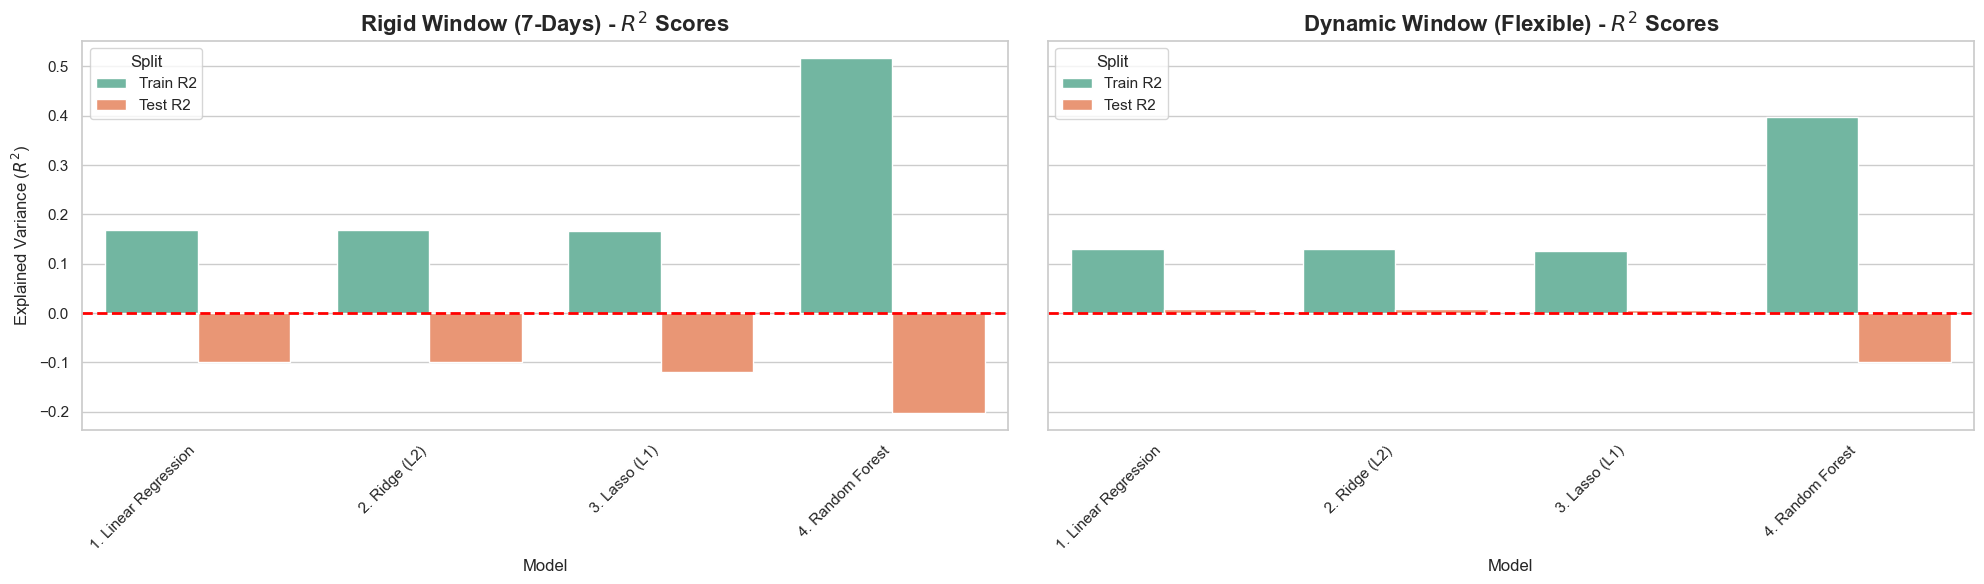

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===")

# 1. סידור הנתונים (Melt) כדי שנוכל להציג Train ו-Test זה לצד זה
df_plot = final_results.melt(
    id_vars=['Dataset', 'Model'], 
    value_vars=['Train R2', 'Test R2'], 
    var_name='Split', 
    value_name='R2 Score'
)

# הגדרת סגנון הגרפים
sns.set_theme(style="whitegrid")

# שימוש ב-sharey=True כדי שציר ה-Y יהיה זהה בשני הגרפים ונזהה הבדלים בקלות
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ---------------------------------------------------------
# גרף ימני (מקום 0 באנגלית): הגישה הקשיחה (Rigid)
# ---------------------------------------------------------
rigid_data = df_plot[df_plot['Dataset'] == 'Rigid (7-Days)']

sns.barplot(data=rigid_data, x='Model', y='R2 Score', hue='Split', ax=axes[0], palette='Set2')
axes[0].set_title('Rigid Window (7-Days) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('Explained Variance ($R^2$)', fontsize=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2) # קו אפס אדום בולט

# ---------------------------------------------------------
# גרף שמאלי (מקום 1 באנגלית): הגישה הדינמית (Dynamic)
# ---------------------------------------------------------
dynamic_data = df_plot[df_plot['Dataset'] == 'Dynamic (Flexible)']

sns.barplot(data=dynamic_data, x='Model', y='R2 Score', hue='Split', ax=axes[1], palette='Set2')
axes[1].set_title('Dynamic Window (Flexible) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('') # הסרנו את התווית כי היא משותפת עם הגרף הראשון
axes[1].axhline(0, color='red', linestyle='--', linewidth=2) # קו אפס אדום בולט

plt.tight_layout()
plt.show()

רואים פשוט אוברפיטינג.. 

כותרת: מתי מדד R2 הופך לשלילי ולמה זה קורה בנתוני מבחן

מתי R2 הופך לשלילי?
השבר של SSres חלקי SStot משווה בין השגיאה של המודל שלך לבין השגיאה של מודל הבסיס:
אם המודל מושלם (SSres שווה 0): R2 שווה 1.
אם המודל מנבא בדיוק כמו ממוצע הנתונים (SSres שווה ל-SStot): R2 שווה 0.
אם המודל גרוע יותר מניחוש הממוצע (SSres גדול מ-SStot): השבר גדול מ-1, ולכן 1 פחות מספר גדול מ-1 ייתן תוצאה שלילית.

למה זה קורה במיוחד בנתוני מבחן (Test Set)?
ברגרסיה ליניארית רגילה על נתוני האימון (Train Set), המודל מותאם מתמטית למזער את SSres, ולכן R2 באימון תמיד יהיה בין 0 ל-1.
אבל כשמעבירים את המודל לנתוני מבחן חדשים (Test Set):
התאמת יתר (Overfitting): המודל שינן את הרעש של נתוני האימון, ובנתונים החדשים הניבויים שלו קופצים רחוק מאוד מהערכים האמיתיים.
זליגת נתונים או שינוי התפלגות: הניבויים כל כך מוטים, עד שלנחש לכל התצפיות במבחן פשוט את ממוצע הנתונים היה מניב שגיאה קטנה יותר מאשר להשתמש בניבויי המודל.

=== צפייה בביצועי כל 8 המודלים ===


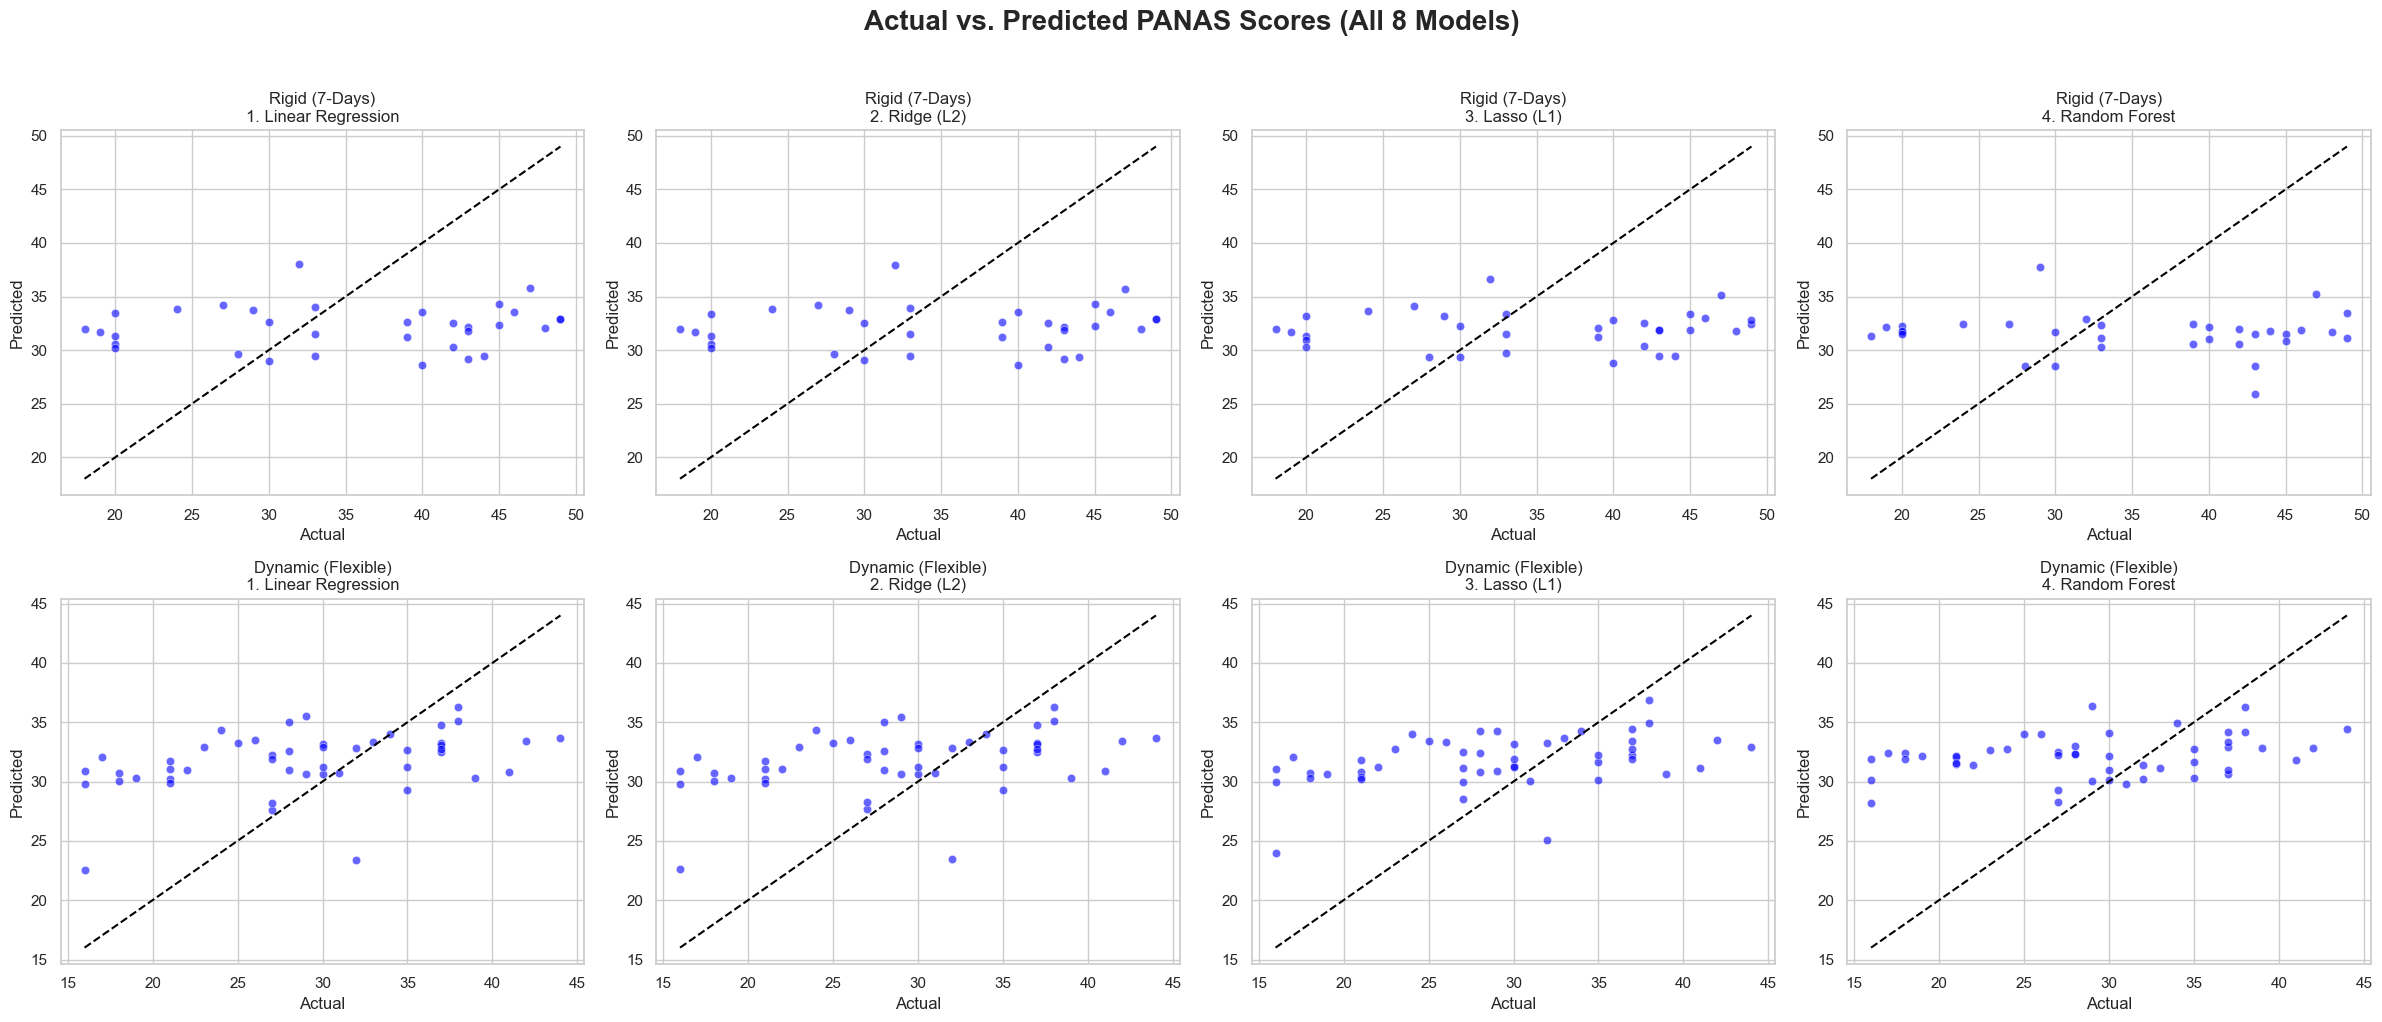

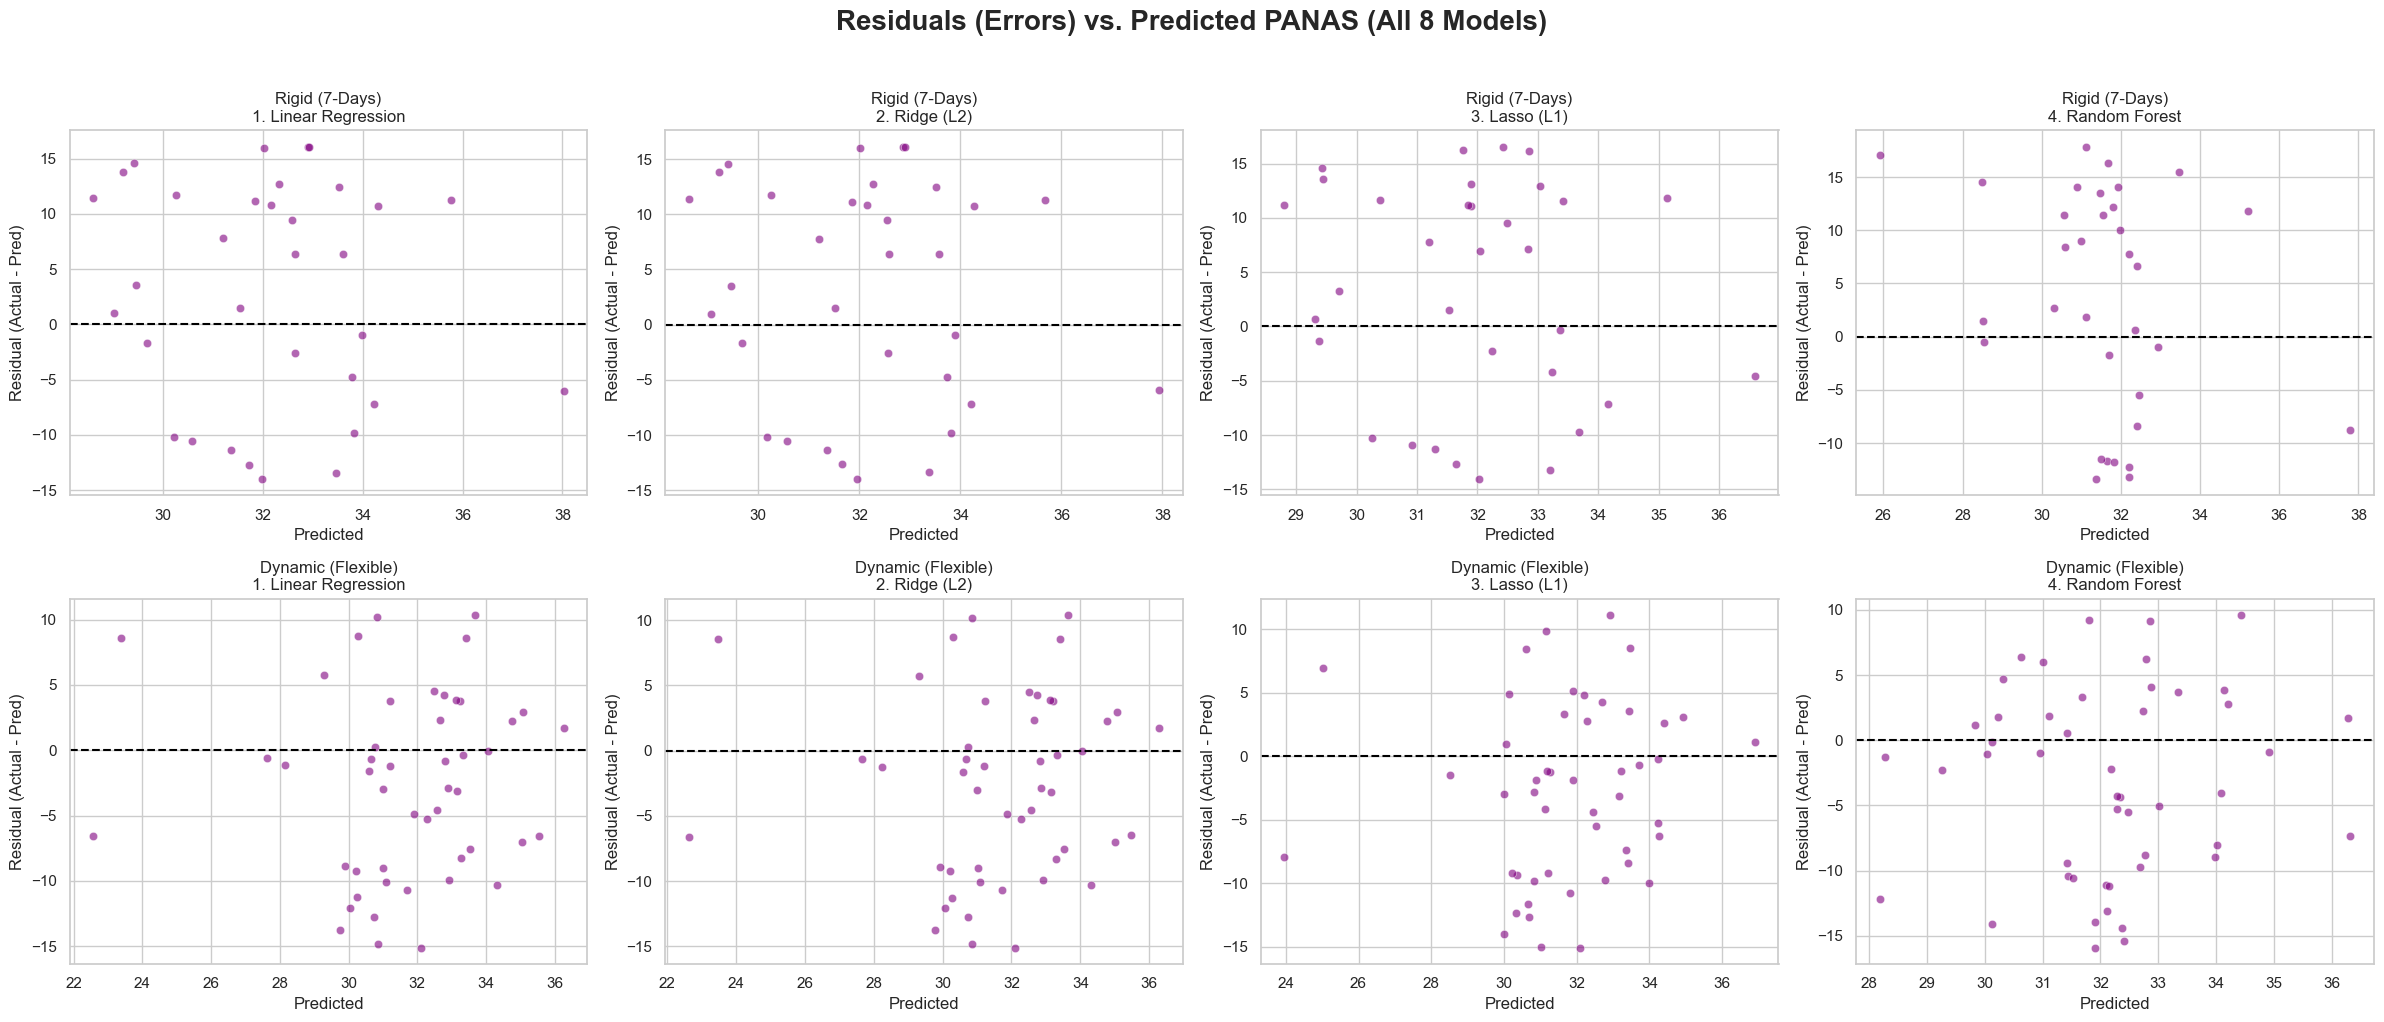

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== צפייה בביצועי כל 8 המודלים ===")

# רשימת הגישות שלנו והנתונים שלהן
datasets = {
    'Rigid (7-Days)': (X_train_R, X_test_R, y_train_R, y_test_R),
    'Dynamic (Flexible)': (X_train_D, X_test_D, y_train_D, y_test_D)
}

# ---------------------------------------------------------
# 1. רשת גרפים: ניבוי מול מציאות (Actual vs Predicted)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(2, 4, figsize=(24, 10))
fig1.suptitle('Actual vs. Predicted PANAS Scores (All 8 Models)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes1[row_idx, col_idx]
        
        # אימון וניבוי ספציפי
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        # ציור פיזור
        sns.scatterplot(x=y_te, y=y_pred, ax=ax, color='blue', alpha=0.6)
        
        # קו המטרה (Perfect Prediction)
        min_val = min(y_te.min(), y_pred.min())
        max_val = max(y_te.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. רשת גרפים: שגיאות / שאריות (Residuals vs Predicted)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 4, figsize=(24, 10))
fig2.suptitle('Residuals (Errors) vs. Predicted PANAS (All 8 Models)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes2[row_idx, col_idx]
        
        # אימון וניבוי (שוב, לוודא נתונים טריים)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        residuals = y_te - y_pred
        
        # ציור פיזור שאריות
        sns.scatterplot(x=y_pred, y=residuals, ax=ax, color='purple', alpha=0.6)
        ax.axhline(0, color='black', linestyle='--') # קו אפס שגיאה
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residual (Actual - Pred)')

plt.tight_layout()
plt.show()

**  הסברים לגרפים**
FIF 1: Actual vs. Predicted PANAS Scores
גרף זה משווה בין ציוני האמת בפועל (ציר X) לניבויי המודלים השונים (ציר Y), כאשר הקו המקווקו (y=x) מייצג ניבוי מושלם. ברוב המודלים (כולל ברגרסיה הליניארית הפשוטה ועיקרי המודלים הקונסים) ניכרת תופעת פשטנות-יתר (Underfitting) חריפה: בעוד ערכי האמת נפרסים על פני טווח נרחב (15–50), הניבויים מרוכזים בטווח צר סביב ממוצע הנתונים בלבד (~29). מכיוון שהתופעה חוזרת גם ללא קנסות רגולריזציה, כנראה שהמקור אינו במנגנון הענישה של המודל אלא בהיעדר קשר ליניארי חזק בין ממוצעי הרגשות השבועיים (EMA) לציוני ה-PANAS, דבר שמוביל את המודלים "להסתפק" בניבוי השואף לממוצע בלבד.

FIG 2: Residuals vs. Predicted PANAS Scores
גרף השאריות מציג את שגיאת המודל (ערך אמת פחות ניבוי) כפונקציה של הערך שנחזה. מודל תקין אמור להציג פיזור אקראי ואחיד סביב קו ה-0; מנגד, הגרפים מראים פיזור לא אחיד של השגיאות (הטרוסקדסטיות ואי-סימטריה) לאורך טווח הניבויים. חוסר האחידות בשגיאות מעיד על כך שהמודלים מתקשים להעריך נכונה מצבי קיצון רגשיים, וכי השגיאות אינן רעש אקראי בלבד. המסקנה המרכזית היא שהאגרגציה השבועית מיסכה את המידע הזמני, ויש צורך בהנדסת מאפיינים ברזולוציה גבוהה יותר (כגון חלונות זמן ממוקדים של 48 שעות) כדי לתפוס את התנודתיות הרגשית.

המעבר מאגרגציה נאיבית להנדסת מאפיינים מבוססת-זמן (Temporal Feature Engineering)
ניתוח ממצאי שלב ה-Baseline
ניתוח תוצאות המודלים הראשוניים בשלב Baseline העלה תובנה קריטית: מודלים שהתבססו על ממוצע פשוט של חלון זמן קבוע של 7 ימים נכשלו בניבוי והציגו R2 שלילי חריף על נתוני המבחן. לעומת זאת, שימוש בחלון זמן דינאמי המתמקד רק בדיווחים רלוונטיים עד לשאלון הקודם בלם את הקריסה במודלים הליניאריים. מודלים אלו הציגו יציבות יחסית והגיעו בנתוני המבחן ל-R2 שקרוב לאפס. כלומר, הם סיפקו ניבוי הקרוב לממוצע הכללי אך לא פגעו בביצועים מעבר לכך. במקביל, במודל היער האקראי Random Forest ניכרה התאמת יתר Overfitting חריפה בשתי הגישות עקב המדגם המצומצם.

הרקע התיאורטי והפסיכולוגי
העובדה שצמצום או התאמת חלון הזמן מנעה הידרדרות לערכים שליליים במודלים הליניאריים, מעידה על כך שחלון זמן דינאמי או קצר יותר מחזיק בערך מוסף. ממצא אמפירי זה מסתדר היטב עם הספרות הפסיכולוגית הקוגניטיבית העוסקת בדיווח רטרוספקטיבי. חישוב ממוצע נאיבי מניח כי לדיווח רגשי מלפני שבוע יש משקל זהה לדיווח מהבוקר. אולם, מילוי שאלוני PANAS מושפע מהטיות זיכרון ידועות: אפקט האחרונות Recency Effect, הגורם לנבדקים לתת משקל יתר לרגשות שחוו ב-48 השעות האחרונות, וחוק השיא והסוף Peak-End Rule של כהנמן, לפיו חוויות מוערכות על בסיס רגעי הקיצון שלהן.

המסקנה המחקרית וצעדי ההמשך
לאור זאת, המסקנה המחקרית היא כי האגרגציה השבועית השטוחה מיסכה את הסיגנל האמיתי בנתונים ויצרה רעש. כדי לשפר את כושר הניבוי, יש צורך בהנדסת מאפיינים Feature Engineering שאינה מתייחסת לזמן כמרחב שטוח, אלא מחלצת מאפיינים מבוססי-הטיה: פיצול חלונות זמן כמו הפרדת 48 השעות האחרונות משאר השבוע, שימוש בפונקציות דעיכה Time-Decay, וזיהוי אירועי קיצון Peaks חיוביים ושליליים.

# שלב 6: הנדסת מאפיינים מבוססת-זמן (Ablation Study: 48h Window vs. Exponential Time-Decay)

בשני התאים הבאים אנו מציגים הנדסת מאפיינים מתקדמת (Feature Engineering) שנועדה לבחון את השערת אפקט האחרונות (Recency Effect) ולהתגבר על בעיית השטת הנתונים שזיהינו במודלי הבסיס. 
במקום לעשות ממוצע שבועי אריתמטי שטוח, אנו מייצרים שתי טבלאות נתונים נפרדות מתוך החלון הדינמי:
1. **טבלת חלונות מפוצלים (`split_window_wide_df`):** מפצלת את הדיווחים בתוך החלון הדינמי לפרופורציית רגשות ב-48 השעות שלפני השאלון לעומת שאר השבוע (ימים 3–7).
2. **טבלת דעיכה בזמן (`decay_wide_df`):** מעניקה לכל דיווח משקל רציף הדועך מעריכית ככל שהדיווח רחוק מתאריך מילוי ה-PANAS ($w = e^{-\lambda \cdot d}$).

בשתי הטבלאות מחושב מדד תנודתיות רגשית (אנטרופיה), ומבוצעת הסרה כפולה/בודדת של קטגוריית הייחוס (`NEUTRAL`) למניעת מולטי-קוליניאריות. לבסוף, מבוצע פיצול מרובד ברמת המשתמש (Stratified Group Split) למניעת זליגת נתונים (Data Leakage) בין האימון למבחן.

In [50]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.model_selection import train_test_split

print("=== שלב 6: הנדסת מאפיינים מתקדמת בחלון דינמי (Dynamic Temporal Feature Engineering) ===")

# הגדרת כלל הרגשות המדויקים כפי שהם מופיעים בטקסט
all_moods = ['ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED']

# העמודה האמיתית שבה שמור הרגש בנתונים שלך
MOOD_COL = 'data.MOOD'

split48_records = []
decay_records = []

# 1. וידוא מיון תאריכים תקין למניעת זליגת נתונים
panas_sorted = panas_base.sort_values(by=['user_id', 'panas_date']).reset_index(drop=True)
ema_sorted = ema_base.sort_values(by=['user_id', 'ema_date']).reset_index(drop=True)

total_panas_count = len(panas_sorted)
dropped_no_ema_count = 0

# =====================================================================
# 2. לולאת חילוץ נתונים מבוססת חלון דינמי
# =====================================================================
for idx, panas_row in panas_sorted.iterrows():
    user = panas_row['user_id']
    p_date = panas_row['panas_date']
    
    # חישוב חלון דינמי
    prev_panas = panas_sorted[(panas_sorted['user_id'] == user) & (panas_sorted['panas_date'] < p_date)]
    if not prev_panas.empty:
        prev_date = prev_panas['panas_date'].max()
        start_date = max(p_date - pd.Timedelta(days=7), prev_date)
    else:
        start_date = p_date - pd.Timedelta(days=7)
        
    # סינון דיווחי ה-EMA של המשתמש בתוך החלון הדינמי בלבד
    mask = (ema_sorted['user_id'] == user) & (ema_sorted['ema_date'] > start_date) & (ema_sorted['ema_date'] <= p_date)
    user_ema = ema_sorted[mask].copy()
    
    # תנאי מחיקה: אם אין דיווחי EMA בחלון
    if len(user_ema) == 0:
        dropped_no_ema_count += 1
        continue

    # חישוב מטא-דאטה של מסגרת הזמן
    actual_window_hours = max((p_date - start_date).total_seconds() / 3600.0, 1.0)
    actual_window_days = actual_window_hours / 24.0
    ema_count = len(user_ema)
    ema_density = ema_count / actual_window_days
    
    base_record = {
        'user_id': user,
        'panas_original_id': panas_row['panas_original_id'],
        'panas_date': p_date,
        'positive_affect_score': panas_row['positive_affect_score'],
        'negative_affect_score': panas_row['negative_affect_score'],
        'total_emas_in_window': ema_count,
        'window_days': round(actual_window_days, 2),
        'ema_density_per_day': round(ema_density, 2)
    }

    # ---------------------------------------------------------
    # אסטרטגיה 1: חלונות מפוצלים בחלון דינמי (SPLIT 48H)
    # ---------------------------------------------------------
    split_rec = base_record.copy()
    threshold_date = p_date - pd.Timedelta(hours=48)
    
    ema_48h = user_ema[user_ema['ema_date'] > threshold_date]
    ema_rest = user_ema[user_ema['ema_date'] <= threshold_date]
    
    # חישוב הפרופורציה (כמה פעמים הרגש מופיע כטקסט בעמודה data.MOOD)
    for m in all_moods:
        split_rec[f'mood_{m}_48h'] = (ema_48h[MOOD_COL] == m).mean() if len(ema_48h) > 0 else 0.0
        split_rec[f'mood_{m}_rest'] = (ema_rest[MOOD_COL] == m).mean() if len(ema_rest) > 0 else 0.0

    # מציאת הרגש הדומיננטי בשאר הימים
    if len(ema_rest) > 0:
        mode_val = ema_rest[MOOD_COL].mode()
        dominant_rest = mode_val.iloc[0] if not mode_val.empty else 'NEUTRAL'
    else:
        dominant_rest = 'NONE'
        
    split_rec['dominant_mood_rest'] = dominant_rest
    split48_records.append(split_rec)
    
    # ---------------------------------------------------------
    # אסטרטגיה 2: דעיכה מעריכית בחלון דינמי (DECAY)
    # ---------------------------------------------------------
    decay_rec = base_record.copy()
    user_ema['delta_days'] = (p_date - user_ema['ema_date']).dt.total_seconds() / 86400.0
    user_ema['weight'] = np.exp(-0.3 * user_ema['delta_days'])
    total_weight = user_ema['weight'].sum()
    
    for m in all_moods:
        # סכימת המשקולות רק עבור השורות שבהן הטקסט שווה לרגש הנוכחי
        m_weight = user_ema.loc[user_ema[MOOD_COL] == m, 'weight'].sum()
        decay_rec[f'mood_{m}_decay'] = m_weight / total_weight if total_weight > 0 else 0.0
        
    decay_records.append(decay_rec)

# יצירת DataFrames
split48_wide_df = pd.DataFrame(split48_records)
decay_wide_df = pd.DataFrame(decay_records)

# =====================================================================
# 3. הנדסת מאפיינים: אנטרופיה והסרת קטגוריית ייחוס למניעת קוליניאריות
# =====================================================================
# SPLIT48
cols_48h = [c for c in split48_wide_df.columns if c.startswith('mood_') and '48h' in c]
cols_rest = [c for c in split48_wide_df.columns if c.startswith('mood_') and 'rest' in c]

split48_wide_df['entropy_48h'] = split48_wide_df[cols_48h].apply(lambda r: entropy(r + 1e-9), axis=1)
split48_wide_df['entropy_rest'] = split48_wide_df[cols_rest].apply(lambda r: entropy(r + 1e-9), axis=1)

split48_wide_df.drop(columns=['mood_NEUTRAL_48h', 'mood_NEUTRAL_rest'], inplace=True, errors='ignore')
split48_wide_df = pd.get_dummies(split48_wide_df, columns=['dominant_mood_rest'], drop_first=True)

# DECAY
cols_decay = [c for c in decay_wide_df.columns if c.startswith('mood_') and 'decay' in c]
decay_wide_df['mood_volatility_entropy'] = decay_wide_df[cols_decay].apply(lambda r: entropy(r + 1e-9), axis=1)
decay_wide_df.drop(columns=['mood_NEUTRAL_decay'], inplace=True, errors='ignore')

# =====================================================================
# 4. הדפסה ופיצול
# =====================================================================
print("\n" + "="*60)
print("📊 סיכום ספירת תצפיות ותנאי סינון")
print("="*60)
print(f"🔹 סה\"כ שאלונים במאגר המקורי (PANAS): {total_panas_count}")
print(f"❌ שאלונים שהושמטו עקב 0 דיווחי EMA בחלון הדינמי: {dropped_no_ema_count}")
print(f"✅ סה\"כ תצפיות סופיות בטבלת SPLIT 48H: {len(split48_wide_df)}")
print(f"✅ סה\"כ תצפיות סופיות בטבלת DECAY: {len(decay_wide_df)}")

split48_train_df, split48_test_df, split48_user_stats = stratified_group_split(
    split48_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

decay_train_df, decay_test_df, decay_user_stats = stratified_group_split(
    decay_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

print("\n--- SPLIT 48H Train Dataset Preview ---")
display(split48_train_df.head(3))

=== שלב 6: הנדסת מאפיינים מתקדמת בחלון דינמי (Dynamic Temporal Feature Engineering) ===

📊 סיכום ספירת תצפיות ותנאי סינון
🔹 סה"כ שאלונים במאגר המקורי (PANAS): 268
❌ שאלונים שהושמטו עקב 0 דיווחי EMA בחלון הדינמי: 54
✅ סה"כ תצפיות סופיות בטבלת SPLIT 48H: 214
✅ סה"כ תצפיות סופיות בטבלת DECAY: 214

--- SPLIT 48H Train Dataset Preview ---


,user_id,panas_original_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,window_days,ema_density_per_day,mood_ALERT_48h,mood_ALERT_rest,...,mood_TIRED_rest,entropy_48h,entropy_rest,dominant_mood_rest_HAPPY,dominant_mood_rest_NEUTRAL,dominant_mood_rest_NONE,dominant_mood_rest_RESTED/RELAXED,dominant_mood_rest_SAD,dominant_mood_rest_TENSE/ANXIOUS,dominant_mood_rest_TIRED
0,621e2eaf67b776a2406b14ac,panas_9,2022-01-05,33,21,2,7.0,0.29,0.500000,0.0,...,0.0,0.693147,1.945910,False,False,True,False,False,False,False
1,621e2eaf67b776a2406b14ac,panas_10,2022-01-07,26,16,6,2.0,3.00,0.166667,0.0,...,0.0,1.560710,1.945910,False,False,True,False,False,False,False
2,621e2eaf67b776a2406b14ac,panas_8,2022-01-10,27,12,7,3.0,2.33,0.000000,0.0,...,0.5,1.332179,0.693147,False,False,False,True,False,False,False


=== שלב 7: אימון והערכת מודלים על מאפייני זמן מתקדמים (Ablation Study) ===

תוצאות ניבוי עבור משתנה המטרה: positive_affect_score


,Dataset,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Split Window (48h/Rest),1. Linear Regression,6.36,8.31,0.271,-0.228
1,Split Window (48h/Rest),2. Ridge (L2),6.36,8.26,0.270,-0.215
2,Split Window (48h/Rest),3. Lasso (L1),6.45,7.97,0.250,-0.131
3,Split Window (48h/Rest),4. Random Forest,5.22,7.36,0.508,0.036
4,Time-Decay (Exponential),1. Linear Regression,6.85,7.88,0.154,-0.105
5,Time-Decay (Exponential),2. Ridge (L2),6.85,7.88,0.154,-0.104
6,Time-Decay (Exponential),3. Lasso (L1),6.86,7.81,0.153,-0.084
7,Time-Decay (Exponential),4. Random Forest,5.57,7.96,0.440,-0.127



=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===


C:\Users\moria\AppData\Local\Temp\ipykernel_25720\1414945936.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\moria\AppData\Local\Temp\ipykernel_25720\1414945936.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


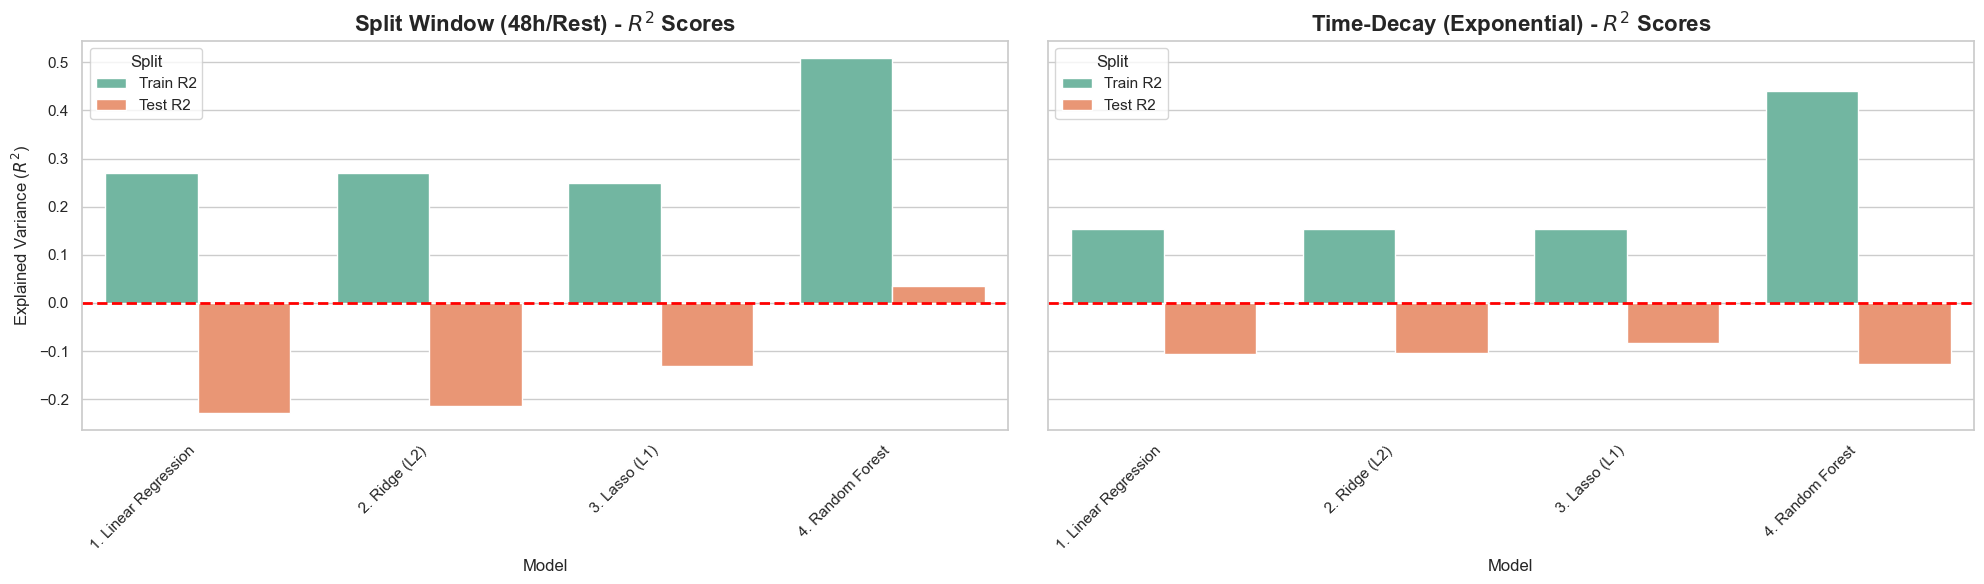


=== צפייה בביצועי כל 8 המודלים (ניתוח שגיאות) ===


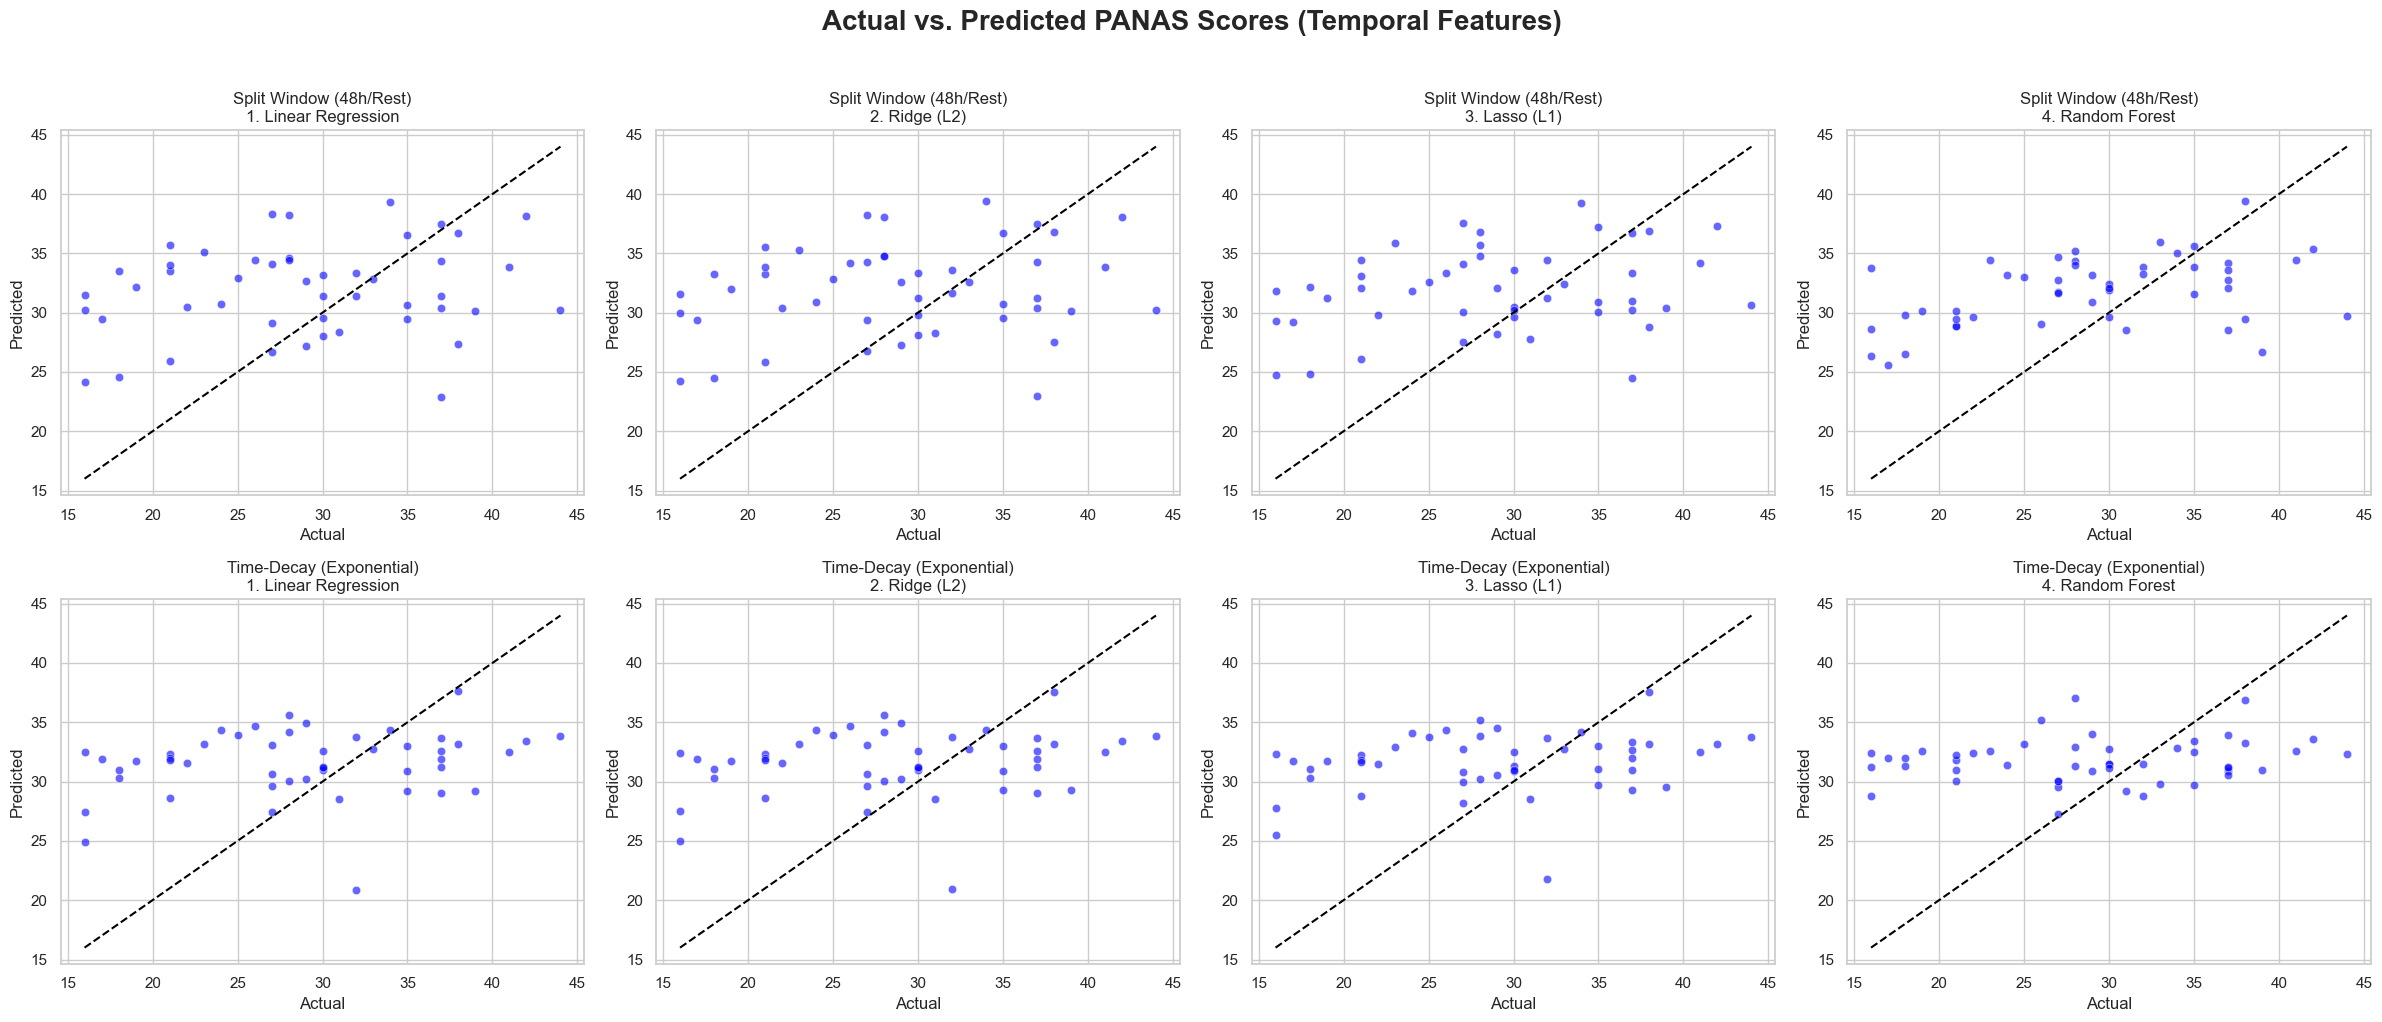

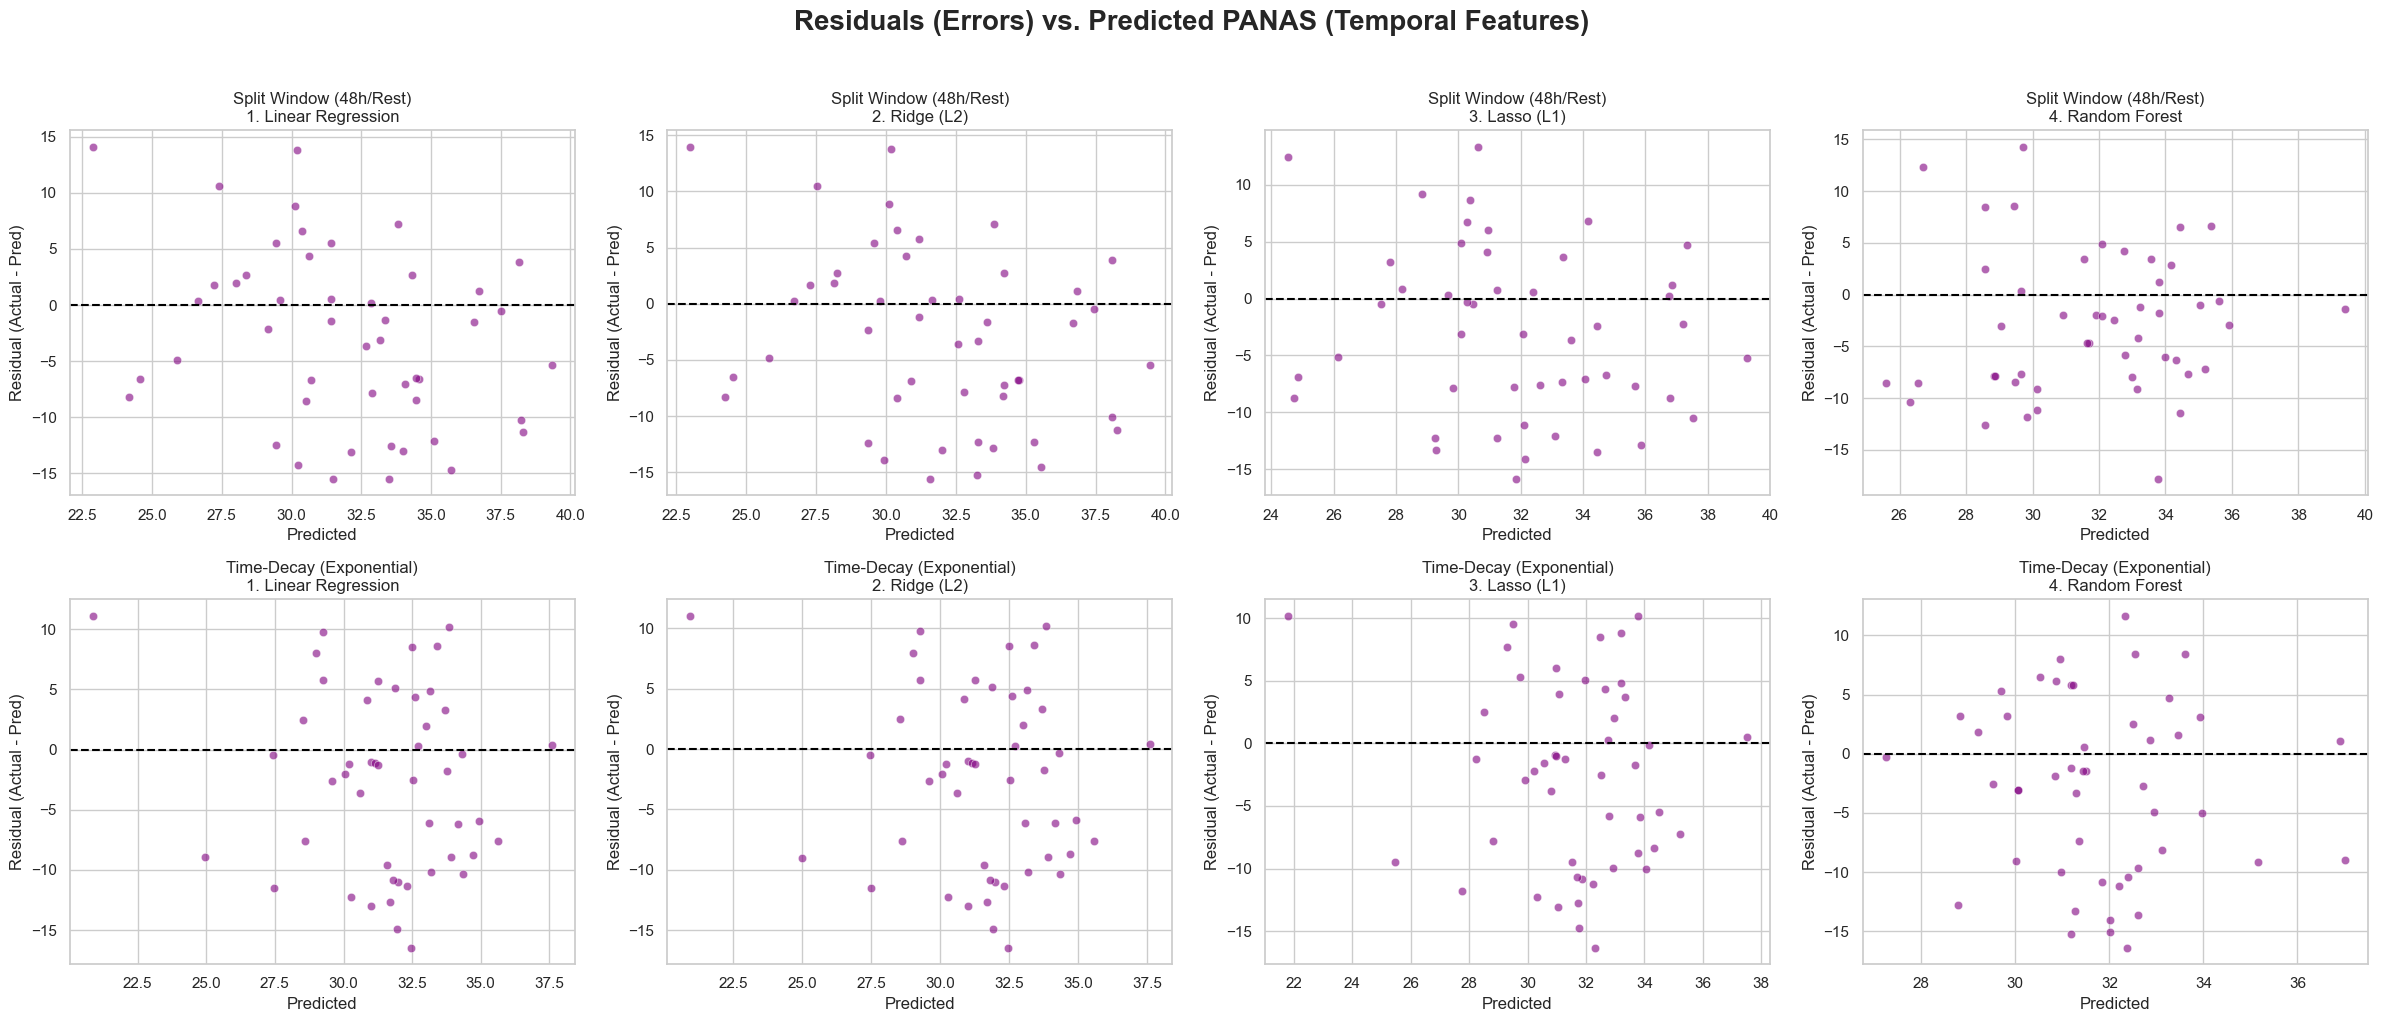

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== שלב 7: אימון והערכת מודלים על מאפייני זמן מתקדמים (Ablation Study) ===")

# הגדרת משתנה המטרה והעמודות שיש להשמיט
TARGET = 'positive_affect_score'
# הוספנו להשמטה גם את משתני המטא-דאטה החדשים כדי שהמודל ילמד רק מהרגשות
DROP_COLS = ['user_id', 'panas_original_id', 'panas_date', 'positive_affect_score', 'negative_affect_score', 
             'total_emas_in_window', 'window_days', 'ema_density_per_day']

# פונקציה להכנת הנתונים (הפרדה וסילום)
def prepare_data(train_df, test_df, target_col, drop_cols):
    # וידוא שעמודות ההשמטה אכן קיימות בטבלה כדי למנוע שגיאות
    cols_to_drop = [c for c in drop_cols if c in train_df.columns]
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df[target_col]
    
    # סילום הנתונים (Standardization)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # החזרת הנתונים המנורמלים כ-DataFrame לשמירה על שמות העמודות
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# הכנת הנתונים לשתי הגישות החדשות
X_train_S, X_test_S, y_train_S, y_test_S = prepare_data(split48_train_df, split48_test_df, TARGET, DROP_COLS)
X_train_D, X_test_D, y_train_D, y_test_D = prepare_data(decay_train_df, decay_test_df, TARGET, DROP_COLS)

# =====================================================================
# הגדרת המודלים
# =====================================================================
models = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge (L2)': Ridge(alpha=1.0),
    '3. Lasso (L1)': Lasso(alpha=0.1),
    '4. Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

# פונקציה לאימון והערכת מילון מודלים
def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'Dataset': dataset_name,
            'Model': name,
            'Train RMSE': round(rmse_train, 2),
            'Test RMSE': round(rmse_test, 2),
            'Train R2': round(r2_train, 3),
            'Test R2': round(r2_test, 3)
        })
        
    return pd.DataFrame(results)

# הרצה ואיחוד התוצאות
results_split = evaluate_models(X_train_S, X_test_S, y_train_S, y_test_S, 'Split Window (48h/Rest)')
results_decay = evaluate_models(X_train_D, X_test_D, y_train_D, y_test_D, 'Time-Decay (Exponential)')

final_results = pd.concat([results_split, results_decay], ignore_index=True)

print(f"\nתוצאות ניבוי עבור משתנה המטרה: {TARGET}\n" + "="*50)
display(final_results)

# =====================================================================
# 1. גרף השוואת R-Squared (אימון מול מבחן)
# =====================================================================
print("\n=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===")

df_plot = final_results.melt(
    id_vars=['Dataset', 'Model'], 
    value_vars=['Train R2', 'Test R2'], 
    var_name='Split', 
    value_name='R2 Score'
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# גרף ימני: גישת החלון המפוצל
split_data = df_plot[df_plot['Dataset'] == 'Split Window (48h/Rest)']
sns.barplot(data=split_data, x='Model', y='R2 Score', hue='Split', ax=axes[0], palette='Set2')
axes[0].set_title('Split Window (48h/Rest) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('Explained Variance ($R^2$)', fontsize=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)

# גרף שמאלי: גישת הדעיכה המעריכית
decay_data = df_plot[df_plot['Dataset'] == 'Time-Decay (Exponential)']
sns.barplot(data=decay_data, x='Model', y='R2 Score', hue='Split', ax=axes[1], palette='Set2')
axes[1].set_title('Time-Decay (Exponential) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('') 
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

# =====================================================================
# 2. רשתות גרפים לניתוח שגיאות (Actual vs Predicted & Residuals)
# =====================================================================
print("\n=== צפייה בביצועי כל 8 המודלים (ניתוח שגיאות) ===")

datasets = {
    'Split Window (48h/Rest)': (X_train_S, X_test_S, y_train_S, y_test_S),
    'Time-Decay (Exponential)': (X_train_D, X_test_D, y_train_D, y_test_D)
}

# רשת 1: ניבוי מול מציאות
fig1, axes1 = plt.subplots(2, 4, figsize=(24, 10))
fig1.suptitle('Actual vs. Predicted PANAS Scores (Temporal Features)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes1[row_idx, col_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        sns.scatterplot(x=y_te, y=y_pred, ax=ax, color='blue', alpha=0.6)
        
        min_val = min(y_te.min(), y_pred.min())
        max_val = max(y_te.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# רשת 2: שאריות
fig2, axes2 = plt.subplots(2, 4, figsize=(24, 10))
fig2.suptitle('Residuals (Errors) vs. Predicted PANAS (Temporal Features)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes2[row_idx, col_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        residuals = y_te - y_pred
        
        sns.scatterplot(x=y_pred, y=residuals, ax=ax, color='purple', alpha=0.6)
        ax.axhline(0, color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residual (Actual - Pred)')

plt.tight_layout()
plt.show()

ממצאי שלב האימון
בשלב זה, בעקבות תיקון תשתית הנתונים והנגשת עמודות הרגש המפורשות, ניכר כי המודלים הצליחו לזהות סיגנל בנתוני האימון (Train Set). המודלים הליניאריים הצליחו להסביר כ-16% מהשונות בנתוני האימון, בעוד שמודל היער האקראי Random Forest הגיע לכושר הסבר מרשים של כ-53% מהשונות (R2 של 0.528). ממצאים אלו מראים כי קיימת חוקיות פנימית בין דיווחי ה-EMA המוקדמים לבין ציוני PANAS בקרב המשתתפים שעל נתוניהם המודל התאמן.

אתגר ההכללה בנתוני המבחן
על אף ההצלחה בשלב האימון, בנתוני המבחן (Test Set) כל המודלים קורסים לערכי R2 שליליים. ניתוח מעמיק של התופעה מעיד כי הסיבה אינה נובעת מחיסרון בכמות השורות או במדגם, אלא מאתגר מתודי מובנה של שונות בין אישית עצומה (Inter-personal Variability). מכיוון שחלוקת הנתונים בוצעה ברמת המשתמש (User-level split) כדי למנוע זליגת מידע, המודל נדרש ללמוד קבוצת נבדקים אחת ולנבא ציונים עבור נבדקים חדשים לחלוטין שהוא מעולם לא נחשף אליהם.

המסקנה המחקרית
הפער החד בין ביצועי האימון לביצועי המבחן מצביע על התאמת יתר (Overfitting) לדפוסי הדיווח הספציפיים של נבדקי האימון. במחקר פסיכולוגי, התרגום הסובייקטיבי של דיווח רגשי רגעי (כמו הדיווח TIRED ב-EMA) לציון מספרי בשאלון PANAS משתנה בין אדם לאדם. כתוצאה מכך, מודלים הלומדים אך ורק תדירויות ופרופורציות של דיווחי רגשות סובייקטיביים מתקשים לייצר חוקיות אוניברסלית המכלילה על משתמשים חדשים. ממצא זה מהווה צידוק מחקרי מרכזי לשילוב נתונים פיזיולוגיים אובייקטיביים בשלבים הבאים, במטרה לספק עוגן פיזיולוגי שיגשר על השונות הבין-אישית.